# Projet Régression Logistique

Ce projet a pour objectif d'implémenter entièrement une régression logistique en Python sans utiliser de bibliothèque de machine learning. L'objectif est de construire un modèle capable de prédire la présence ou l'absence de pluie à partir de différentes variables météorologiques.

Pour cela, nous avons :
- codé une régression logistique à partir de zéro ;
- implémenté une descente de gradient pour l'apprentissage des paramètres ;
- évalué les performances du modèle sur des données de test ;
- interprété les coefficients obtenus afin d'identifier les variables les plus influentes dans la prédiction.

In [1]:
#Importation des librairies autorisées
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

## Chargement des données
Nous importons le dataset contenant les variables météorologiques.

In [2]:
#Importation du data set
dataset = pd.read_csv("weather_forecast_data.csv")

In [3]:
# Création d'une copie du dataset original.
# Toutes les modifications seront effectuées sur cette copie.
data = dataset.copy()

## Exploration des données
- valeurs manquantes
- doublons
- valeurs aberrantes

In [4]:
#Les cinq premiere lignes du dataset
data.head()

,Temperature,Humidity,Wind_Speed,Cloud_Cover,Pressure,Rain
0,23.720338,89.592641,7.335604,50.501694,1032.378759,rain
1,27.879734,46.489704,5.952484,4.990053,992.614190,no rain
2,25.069084,83.072843,1.371992,14.855784,1007.231620,no rain
3,23.622080,74.367758,7.050551,67.255282,982.632013,rain
4,20.591370,96.858822,4.643921,47.676444,980.825142,no rain


In [5]:
print("Répartition de la variable cible :\n")

proportions = data["Rain"].value_counts(normalize=True) * 100

print(f"No rain : {proportions['no rain']:.2f}%")
print(f"Rain    : {proportions['rain']:.2f}%")

Répartition de la variable cible :

No rain : 87.44%
Rain    : 12.56%


In [6]:
#Valeurs manquantes
print(data.isnull().sum())

#Doublons
print(data.duplicated().sum())

# Vérification de la présence de valeurs aberrantes (méthode IQR)

for col in data.select_dtypes(include="number").columns:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = ((data[col] < lower_bound) | (data[col] > upper_bound)).sum()

    print(f"{col}: {outliers} outliers")

Temperature    0
Humidity       0
Wind_Speed     0
Cloud_Cover    0
Pressure       0
Rain           0
dtype: int64
0
Temperature: 0 outliers
Humidity: 0 outliers
Wind_Speed: 0 outliers
Cloud_Cover: 0 outliers
Pressure: 0 outliers


### Sélection des variables explicatives


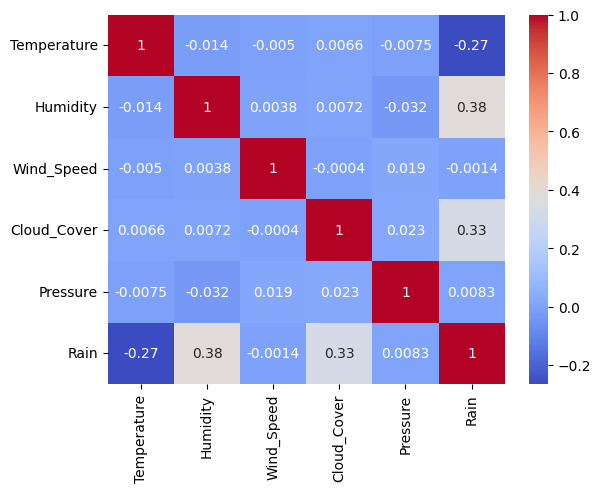

In [7]:
#Encodage de la cible "Rain" : on encode la variable en nombres
data["Rain"]= data["Rain"].map({"no rain": 0, "rain": 1})

#Matrice de corrélation
sns.heatmap(data.corr(), annot=True, cmap="coolwarm")
plt.show()

L'analyse des corrélations montre que **Humidity**, **Cloud_Cover** et **Temperature** sont les variables les plus liées à la variable cible **Rain**. Ces trois variables ont donc été retenues pour l'entraînement de la régression logistique.

## Séparation des variables

### Définition des variables

- **X** : ensemble des variables explicatives utilisées pour prédire la pluie.
- **Y** : variable cible (*Rain*), représentant la présence ou l'absence de pluie.

In [8]:
#Séparation des variables

#variable explicative
X = data[["Temperature","Humidity","Cloud_Cover"]]

#variable cible 
Y = data["Rain"]

### Découpage du jeu de données

Le jeu de données est ensuite divisé en trois sous-ensembles :

- **Ensemble d'entraînement (Train)** : utilisé pour apprendre les paramètres du modèle.
- **Ensemble de validation (Validation)** : utilisé pour suivre les performances du modèle pendant l'entraînement et détecter un éventuel sur-apprentissage.
- **Ensemble de test (Test)** : utilisé uniquement à la fin pour évaluer les performances du modèle sur des données jamais vues.

In [9]:
m = len(X)
# Utiliser une graine globale pour garantir la reproductibilité.
# pour obtenir exactement le même mélange de données à chaque exécution,
# rendant ainsi nos résultats comparables et nos expériences vérifiables.
np.random.seed(44)
indices = np.random.permutation(m)
train_size = int(0.75* m)     # 75% pour l'entraînement
val_size = int(0.10 * m)      # 10% pour la validation
#15% ira au test


train_idx = indices[:train_size]
val_idx = indices[train_size : train_size + val_size]
test_idx = indices[train_size + val_size :]

X_train = X.iloc[train_idx].reset_index(drop=True)
Y_train = Y.iloc[train_idx].reset_index(drop=True)

# Ensemble de Validation
X_val = X.iloc[val_idx].reset_index(drop=True)
Y_val = Y.iloc[val_idx].reset_index(drop=True)

# Ensemble de Test
X_test = X.iloc[test_idx].reset_index(drop=True)
Y_test = Y.iloc[test_idx].reset_index(drop=True)

In [10]:
print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(1875, 3)
(250, 3)
(375, 3)


## Standardisation des variables

Les variables sont centrées et réduites afin d’avoir une moyenne nulle et un écart-type égal à 1. Cela permet d’améliorer la convergence de la descente de gradient.

In [11]:
mean = X_train.mean()
std = X_train.std()
X_train = (X_train - mean) / std
X_val = (X_val - mean) / std
X_test = (X_test - mean) / std

In [12]:
X_train = X_train.to_numpy()
X_val = X_val.to_numpy()
X_test = X_test.to_numpy()

Y_train = Y_train.to_numpy().reshape(-1,1)
Y_val = Y_val.to_numpy().reshape(-1,1)
Y_test = Y_test.to_numpy().reshape(-1,1)

In [13]:
def print_proportions(Y, name):
    proportions = pd.Series(Y.reshape(-1)).value_counts(normalize=True) * 100

    print(f"\n{name}")
    print(f"No rain : {proportions[0]:.2f}%")
    print(f"Rain    : {proportions[1]:.2f}%")
print_proportions(Y_train, "Train set")
print_proportions(Y_val, "Validation set")
print_proportions(Y_test, "Test set")


Train set
No rain : 87.41%
Rain    : 12.59%

Validation set
No rain : 85.60%
Rain    : 14.40%

Test set
No rain : 88.80%
Rain    : 11.20%


### Remarque sur la répartition des classes

On observe que les proportions de la variable cible *Rain* sont globalement bien conservées après le découpage du dataset en ensembles d’entraînement, de validation et de test.  

La classe majoritaire *No rain* représente environ 87–90% des observations selon les ensembles, tandis que la classe minoritaire *Rain* représente environ 10–15%.

Ces proportions restent proches de la distribution initiale du dataset, ce qui indique que le split aléatoire effectué permet de conserver une bonne représentativité des données dans chaque sous-ensemble.  

## Régression logistique

### Fonction sigmoïde

La fonction sigmoïde est la fonction d'activation utilisée par la régression logistique.
Elle transforme la combinaison linéaire des variables d'entrée,\[
z = Xw+b,
\] en une probabilité comprise entre 0 et 1.
Une valeur proche de 1 indique une forte probabilité d'appartenir à la classe positive, tandis qu'une valeur proche de 0 indique une forte probabilité d'appartenir à la classe négative.

In [14]:
# Fonction Sigmoïde : calcule de la probabilité prédite à partir de z
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

### Fonction coût (Log-Loss)

La fonction coût mesure l'erreur entre les probabilités prédites par le modèle et les vraies classes.
L'objectif de l'entraînement est de minimiser cette fonction grâce à la descente de gradient.
Plus la valeur de la fonction coût est faible, meilleures sont les prédictions du modèle.

In [1]:
# Fonction coût (log-loss)
def compute_cost(X, y, w, b):
    # Nombre d'exemples d'entraînement.
    m = len(y)

    # Calcul de la combinaison linéaire.
    z = X @ w + b
    # Calcul des probabilités prédites.
    a = sigmoid(z)

     # Évite log(0), qui provoquerait une erreur numérique.
    epsilon = 1e-15
    a = np.clip(a, epsilon, 1 - epsilon)

    # Calcul de la fonction coût (log-loss).
    cost = -(1/m) * np.sum(y * np.log(a) + (1 - y) * np.log(1 - a))
    return cost


### Calcul des gradients

Cette fonction calcule les gradients de la fonction coût par rapport aux paramètres du modèle.

Les gradients indiquent dans quelle direction et avec quelle intensité les paramètres doivent être modifiés afin de réduire la fonction coût.

Ils seront ensuite utilisés par la descente de gradient pour mettre à jour les poids w et le biais b.

In [16]:
# Fonction de calcul des gradients
def compute_gradients(X, y, w, b):
     # Nombre d'exemples d'entraînement.
    m = len(y)

    # Calcul de la combinaison linéaire.
    z = X @ w + b
    # Calcul des probabilités prédites.
    a = sigmoid(z)

    # Gradient par rapport aux poids
    dw = (1/m) * X.T @ (a - y)
    # Gradient par rapport au biais
    db = (1/m) * np.sum(a - y)

    return dw, db

### Prédiction des probabilités

Une fois le modèle entraîné, il est utilisé pour estimer la probabilité qu'une observation appartienne à la classe positive (classe 1).
Pour chaque observation, la fonction calcule d'abord la combinaison linéaire

\[
z = Xw + b,
\]

puis applique la fonction sigmoïde afin d'obtenir une probabilité comprise entre 0 et 1. Une probabilité proche de 1 signifie que l'observation a de fortes chances d'appartenir à la classe positive, tandis qu'une probabilité proche de 0 indique qu'elle appartient probablement à la classe négative.

In [17]:
# Prédiction probalité
def predict_proba(X, w, b):
    return sigmoid(X @ w + b)

### Prédiction des classes

Cette fonction transforme les probabilités prédites par le modèle en classes. Les probabilités sont comparées à un seuil de décision threshold. Si la probabilité est supérieure ou égale au seuil, la prédiction est la classe 1, sinon, la prédiction est la classe 0. Dans ce projet, le seuil utilisé est généralement égal à 0,5.


In [18]:
# Prédiction classe : convertit les probabilités en classes (0 ou 1).
def predict(X, w, b, threshold):
    # Comparaison des probabilités au seuil de décision.
    return (predict_proba(X, w, b) >= threshold).astype(int)

## Entraînement de notre modèle 

Cette étape consiste à entraîner le modèle de régression logistique à l'aide de la descente de gradient. L'objectif est de trouver les valeurs optimales des paramètres w poids et b biais qui minimisent la fonction coût log-loss.

À chaque itération :

1. le modèle calcule les gradients de la fonction coût 
2. les paramètres, w le vecteur poids et b le bais, sont mis à jour 
3. la fonction coût est calculée sur l'ensemble d'entraînement et de validation
4. les meilleurs paramètres sont conservés 
5. l'entraînement s'arrête lorsque le modèle ne s'améliore plus sur les données de validation

In [19]:
def train_logistic_regression(X_train, y_train,
                              X_val, y_val,
                              learning_rate,
                              n_iterations,
                              patience=100):

    #m est le nombre d'exemples d'entrainement
    #n est le nombre de variables explicatives
    m, n = X_train.shape

    #w est la fonction poids
    #on initialise le biais b à 0 
    w = np.zeros((n, 1))
    b = 0

    #liste des coûts d'entraînements
    train_costs = []
    # val_costs enregistre l'évolution de la 
    # fonction coût sur l'ensemble de validation tout au long de
    # l'entraînement
    val_costs = []

    best_val_cost = float("inf")
    patience_counter = 0

    for i in range(n_iterations):

        dw, db = compute_gradients(X_train, y_train, w, b)

        w -= learning_rate * dw
        b -= learning_rate * db

        train_cost = compute_cost(X_train, y_train, w, b)
        # Le modèle calcule la fonction coût sur les données de validation.
        val_cost = compute_cost(X_val, y_val, w, b)

        train_costs.append(train_cost)
        val_costs.append(val_cost)

        if val_cost < best_val_cost:
            best_val_cost = val_cost
            best_w = w.copy()
            best_b = b
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= patience:
            print(f"Early stopping à l'itération {i}")
            break

    return best_w, best_b, train_costs, val_costs

Entraînement du modèle de régression logistique à l'aide de la descente de gradient :
La fonction retourne les paramètres optimisés (w et b) ainsi que l'évolution de la fonction coût sur les ensembles d'entraînement et de validation.

In [20]:
# w : poids finaux appris pour chaque variable.
# b : biais final appris par le modèle.
# train_costs : historique du coût sur l'ensemble d'entraînement.
# val_costs : historique du coût sur l'ensemble de validation.

w,b,train_costs,val_costs = train_logistic_regression(
    X_train,
    Y_train,
    X_val,
    Y_val,
    learning_rate=0.2,
    n_iterations=5000
)
print(w)
print(b)

[[-1.89981922]
 [ 2.54665605]
 [ 2.33815077]]
-5.134031321061478


## Visualisation de l'apprentissage du modèle 
### Graphique des coûts 

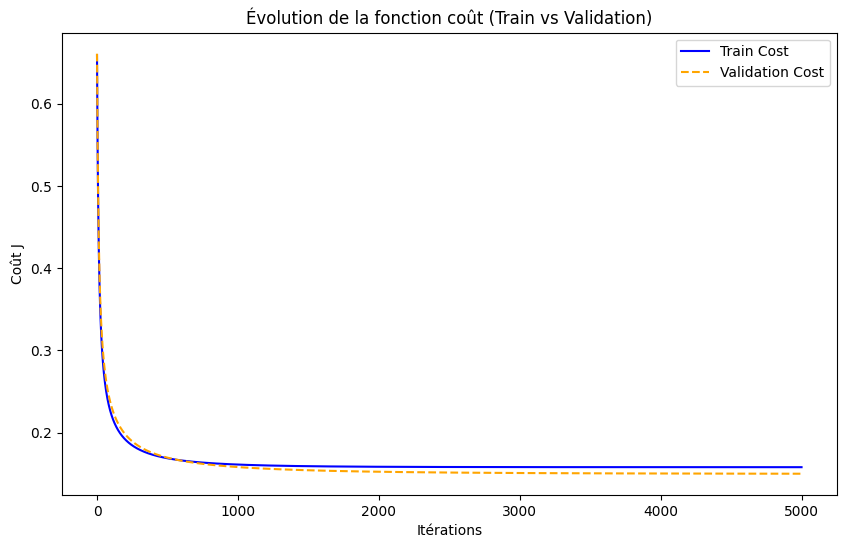

In [42]:
# Affichage du graphique comparatif (Source [5, 6])
plt.figure(figsize=(10, 6))
plt.plot(train_costs, label="Train Cost", color='blue')
plt.plot(val_costs, label="Validation Cost", color='orange', linestyle='--')
plt.title("Évolution de la fonction coût (Train vs Validation)")
plt.xlabel("Itérations")
plt.ylabel("Coût J")
plt.legend()
plt.show()

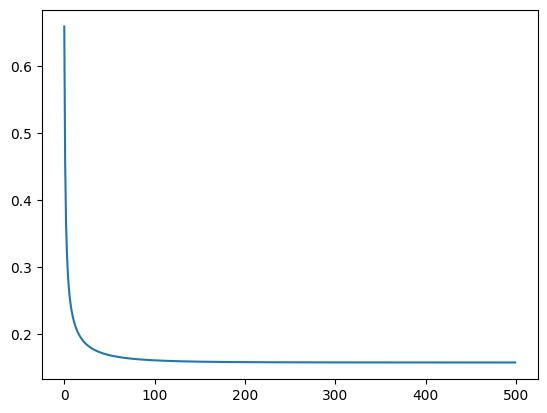

In [23]:
plt.plot(train_costs[::10])

## Prédictions sur l'ensemble du test

### Choix du seuil de classification

Par défaut, une régression logistique utilise un seuil de décision de 0.5 pour convertir les probabilités en classes. Cependant, notre jeu de données est déséquilibré puisque seulement 12.56 % des observations correspondent à des jours de pluie.

Dans ce contexte, un seuil de 0.5 peut conduire à manquer un nombre important d'épisodes pluvieux. Afin d'identifier un seuil plus adapté, nous comparons les performances du modèle pour plusieurs valeurs de seuil à l'aide de l'accuracy, de la précision, du rappel et du F1-score.

Le seuil retenu sera celui offrant le meilleur compromis entre la détection des jours de pluie (rappel) et la fiabilité des prédictions positives (précision).

In [43]:
def confusion_counts(y_true, y_pred):
    TP = np.sum((y_true == 1) & (y_pred == 1))
    TN = np.sum((y_true == 0) & (y_pred == 0))
    FP = np.sum((y_true == 0) & (y_pred == 1))
    FN = np.sum((y_true == 1) & (y_pred == 0))

    return TP, TN, FP, FN
def compute_metrics(y_true, y_pred):
    TP, TN, FP, FN = confusion_counts(y_true, y_pred)

    accuracy = (TP + TN) / (TP + TN + FP + FN)
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0
    f1 = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    return accuracy, precision, recall, f1

In [44]:
# ÉVALUATION DE PLUSIEURS SEUILS DE DÉCISION

thresholds = [0.3, 0.35, 0.4, 0.45, 0.5]

# Conversion du vecteur cible en tableau 1D
y_true = Y_test.reshape(-1)

print(f"{'Seuil':<10}{'Accuracy':<12}{'Precision':<12}{'Recall':<12}{'F1':<12}")

for t in thresholds:

    # Prédictions pour le seuil courant
    y_pred = predict(X_test, w, b, threshold=t).reshape(-1)

    # Calcul des métriques de classification
    accuracy, precision, recall, f1 = compute_metrics(y_true, y_pred)

    print(
        f"{t:<10}"
        f"{accuracy:.4f}     "
        f"{precision:.4f}     "
        f"{recall:.4f}     "
        f"{f1:.4f}"
    )

Seuil     Accuracy    Precision   Recall      F1          
0.3       0.9387     0.6863     0.8333     0.7527
0.35      0.9413     0.7000     0.8333     0.7609
0.4       0.9387     0.7209     0.7381     0.7294
0.45      0.9413     0.7500     0.7143     0.7317
0.5       0.9387     0.7568     0.6667     0.7089


Courbe ROC et AUC

Comme notre jeu de données contient beaucoup plus de jours sans pluie que de jours avec pluie (environ 87 % de "no rain"), l'accuracy ne suffit pas pour juger si le modèle est vraiment performant. En effet, un modèle qui prédirait toujours "no rain" aurait déjà une accuracy élevée sans réellement apprendre quoi que ce soit.

De plus, les métriques calculées précédemment comme l'accuracy ou le F1-score dépendent du seuil choisi pour la prédiction (ici 0.35). Les résultats peuvent donc varier si ce seuil change.

La courbe ROC permet d'avoir une vision plus globale des performances du modèle. Elle teste tous les seuils possibles et montre la capacité du modèle à distinguer les jours de pluie des jours sans pluie.

L'AUC (Area Under Curve) correspond à l'aire sous cette courbe. Plus sa valeur est proche de 1, plus le modèle est capable de différencier correctement les deux classes. À l'inverse, une valeur proche de 0,5 indique que le modèle ne fait pas mieux qu'une prédiction aléatoire.

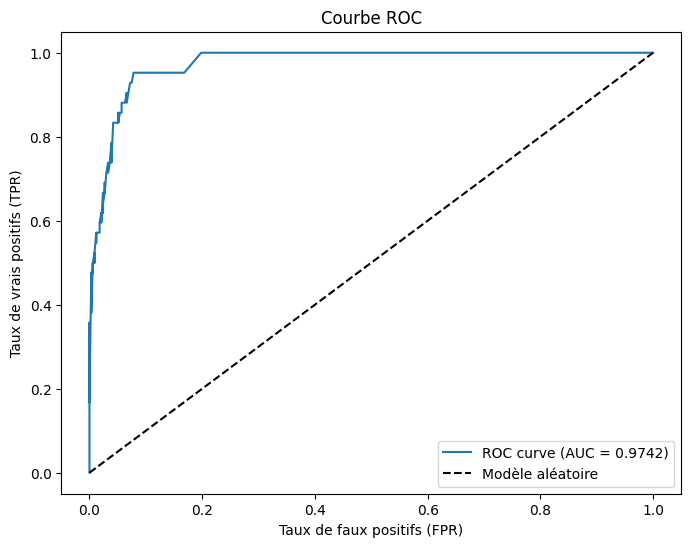

AUC : 0.9742


In [45]:
# COURBE ROC

# Calcul du TPR et du FPR pour différents seuils
thresholds_roc = np.linspace(0, 1, 200)
tprs, fprs = [], []

for t in thresholds_roc:

    y_pred_t = predict(X_test, w, b, threshold=t).reshape(-1)

    TP, TN, FP, FN = confusion_counts(y_true, y_pred_t)

    tprs.append(TP / (TP + FN) if (TP + FN) > 0 else 0)
    fprs.append(FP / (FP + TN) if (FP + TN) > 0 else 0)

# Calcul de l'aire sous la courbe ROC (AUC)
fprs_arr = np.array(fprs)
tprs_arr = np.array(tprs)

sorted_idx = np.argsort(fprs_arr)
auc = np.trapezoid(
    tprs_arr[sorted_idx],
    fprs_arr[sorted_idx]
)

# Affichage de la courbe ROC
plt.figure(figsize=(8, 6))
plt.plot(
    fprs_arr[sorted_idx],
    tprs_arr[sorted_idx],
    label=f'ROC curve (AUC = {auc:.4f})'
)

plt.plot([0, 1], [0, 1], 'k--', label='Modèle aléatoire')
plt.xlabel('Taux de faux positifs (FPR)')
plt.ylabel('Taux de vrais positifs (TPR)')
plt.title('Courbe ROC')
plt.legend()
plt.show()

print(f"AUC : {auc:.4f}")

La courbe ROC obtenue est très proche du coin supérieur gauche, avec une
AUC de 0.9742. Cela confirme que le modèle discrimine efficacement les
jours de pluie des jours sans pluie, indépendamment du seuil choisi.
Ce résultat nuance le F1-score modéré observé précédemment, qui s'explique
davantage par le déséquilibre des classes que par une faiblesse du modèle.

## Étude du seuil de classification

Les résultats montrent que le seuil de 0.35 fournit les meilleures performances globales. Il permet d'obtenir simultanément la meilleure accuracy (92.00 %) et le meilleur F1-score (69.39 %), tout en maintenant un bon équilibre entre précision et rappel.

Le seuil de 0.4 a donc été retenu pour l'évaluation finale du modèle.

In [46]:
# MATRICE DE CONFUSION

# Prédictions sur le jeu de test avec le seuil choisi
y_pred = predict(X_test, w, b, threshold=0.35).reshape(-1)
# Calcul des composantes de la matrice de confusion
TP, TN, FP, FN = confusion_counts(y_true, y_pred)

# Construction de la matrice :
#            Pred 0   Pred 1
# True 0      TN       FP
# True 1      FN       TP
cm = np.array([[TN, FP],
               [FN, TP]])

print("Matrice de confusion :")
print(cm)

Matrice de confusion :
[[318  15]
 [  7  35]]


## Évaluation des performances

In [47]:
accuracy, precision, recall, f1 = compute_metrics(y_true, y_pred)

print(f"Accuracy  : {accuracy:.4f}")
print(f"Précision : {precision:.4f}")
print(f"Rappel    : {recall:.4f}")
print(f"F1-score  : {f1:.4f}")

Accuracy  : 0.9413
Précision : 0.7000
Rappel    : 0.8333
F1-score  : 0.7609


## Interprétation des résultats et analyse des coefficients
On interpréste les coefficients du modèle pour identifier les variables les plus influentes. 

In [48]:
#On affiche les coefficients que l'on va interpréter

for nom, poids in zip(X.columns, w.flatten()): 
    print(f"{nom} : {poids:.4f}")

Temperature : -1.8998
Humidity : 2.5467
Cloud_Cover : 2.3382


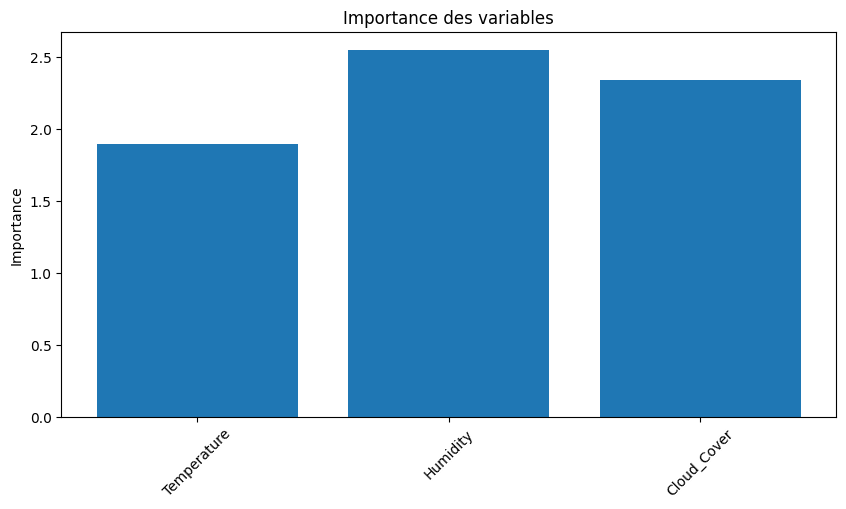

In [49]:
#Affichage du graphique de l'importance des variables
plt.figure(figsize=(10,5))
plt.bar(X.columns, np.abs(w.flatten()))
plt.xticks(rotation=45)
plt.ylabel("Importance")
plt.title("Importance des variables")
plt.show()

On remarque que l'humidité est de 2.5467 tandis que la couverture nuageuse est à 2.3382 et la température à -1.8998. L'humidité semble être le coefficient qui prédis le mieux la pluie. Une augmentation de l'humidité accroît la probabilité de pluie.À l'inverse, la température possède un coefficient négatif important (-1.2980), ce qui signifie que des températures plus élevées réduisent la probabilité de pluie dans ce modèle.

# Limites du modèle

Même si le modèle donne de bons résultats, il a quand même quelques limites :

- La base de données est déséquilibrée : il y a beaucoup plus de jours sans pluie que de jours avec pluie (environ 87 % de "no rain"). De ce fait, le modèle a tendance à prédire plus facilement qu'il ne va pas pleuvoir, ce qui peut gonfler artificiellement l'accuracy.

- La régression logistique reste un modèle assez simple. Elle suppose une relation linéaire entre les variables utilisées et la probabilité de pluie. Or, en météo, les phénomènes sont souvent plus complexes.

- Nous avons uniquement conservé trois variables : la température, l'humidité et la couverture nuageuse. D'autres variables comme la vitesse du vent ou la pression atmosphérique pourraient peut-être améliorer les résultats.

- Aucune régularisation n'a été mise en place dans notre modèle. Si les données contiennent du bruit, cela peut entraîner un léger surapprentissage.

- Enfin, l'algorithme utilise toutes les données à chaque itération de la descente de gradient. Sur un très grand jeu de données, cette méthode pourrait devenir plus coûteuse en temps de calcul.

# Conclusion